# ПРОЕКТ: Нейросеть для автопродления текстов
## Загрузка и первичный просмотр данных

In [1]:
# =========================
# Standard Library
# =========================

import random

# =========================
# Third-Party Imports
# =========================

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

from datasets import Dataset

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import (AutoTokenizer,
                          PreTrainedTokenizerBase,
                          AutoModelForCausalLM,
                          logging)

# =========================
# Local Imports
# =========================

# классы датасетов
from src.lstm_datasets import TrainDataset, EvalDataset

# модель LSTM
from src.lstm_model import SequencePredictionLSTM

# функция обучения
from src.lstm_train import train

# вспомогательные функции
from src.utils import (get_device, # выбор 'cpu', 'mps' или 'cuda'
                       clean_string_lstm, # чистка для LSTM
                       clean_string_transformer, # чистка для transformer (менее агресивная)
                       save_model_dict, # сохранение весов для LSTM модели
                       load_model_params_from_dict, # загрузка весов для LSTM модели
                       drop_short_texts, # удаление коротких текстов менее min_len
                       drop_long_texts, # удаление длинных текстов более max_len
                       split_text, # разделение текста на 3/4 (input) и 1/4 (target)
                       prepare_data_for_transformer)

# загрузка данных
from src.data_download import load_sentiment140_csv

# функции для оценки качества моделей
from src.evaluation import (evaluate_rouge_transformer,
                            lstm_generate_text_examples,
                            transformer_generate_text_examples)

# =========================
# Constants / Config
# =========================

# отношения размерностей выборок
TEST_VAL_SIZE = 0.2
TEST_SIZE = 0.5

# параметры обучения
BATCH_SIZE = 128
BATCH_SIZE_TRANSFORMER = 64
LEARNING_RATE = 1e-3
EPOCHS = 10
FACTOR = 0.5 # коэффициент уменьшения LR
PATIENCE = 2 # уменьшение LR если в течение двух эпох метрика не улучшится

# параметры моделей
MODEL_NAME = 'distilgpt2'
LSTM_HIDDEN_STATE = 128
PAD_TOKEN_ID = 0

# фиксация генераторов случайных чисел для воспроизводимости
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# опции вывода таблиц pandas
pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)

# отключение лишнего логгирования
logging.set_verbosity_error()

torch.cuda.empty_cache()

In [2]:
# загрузка/сохранение датасета
data = load_sentiment140_csv()

In [3]:
# первичный просмотр
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   text       1600000 non-null  object
 1   date       1600000 non-null  object
 2   user       1600000 non-null  object
 3   sentiment  1600000 non-null  int64 
 4   query      1600000 non-null  object
dtypes: int64(1), object(4)
memory usage: 61.0+ MB


1600000 текстов. Нас интересует только колонка `text` (сами тексты).

In [4]:
# выбираем тексты
data = data[['text']]

## Анализ количества слов в текстах

In [5]:
# статистика по количеству слов
word_counts = [len(t.split()) for t in data['text'].values]
print("\nСтатистика по количеству слов в тексте:")
print("Среднее: ", np.mean(word_counts))# посчитайте среднее кол-во слов в текстах
print("Медиана: ", np.median(word_counts))# посчитайте медианное кол-во слов в текстах
print("5-й перцентиль: ", np.percentile(word_counts, 5))# посчитайте 5-й перцентиль кол-ва слов в текстах
print("95-й перцентиль: ", np.percentile(word_counts, 95))# посчитайте 95-й перцентиль кол-ва слов в текстах


Статистика по количеству слов в тексте:
Среднее:  13.17810875
Медиана:  12.0
5-й перцентиль:  3.0
95-й перцентиль:  25.0


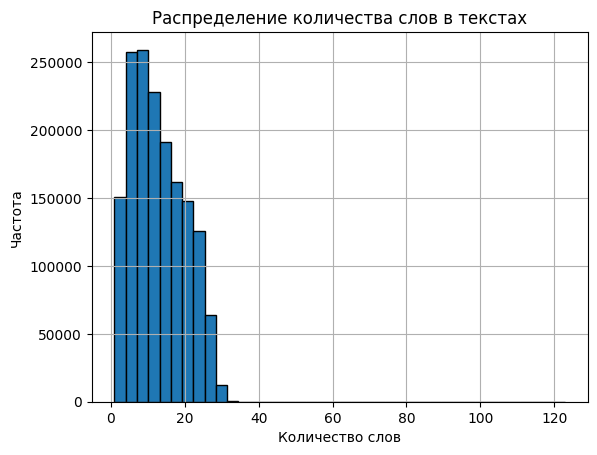

In [6]:
# гистограмма распределения длины
plt.hist(word_counts, bins=40, edgecolor='black')
plt.title("Распределение количества слов в текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Имеет смысл ограничиться длинами от 3 до 26 слов.

In [7]:
min_length = 3
max_length = 26
max_length_with_eos = max_length + 1 # длина текста с учетом токена окончания последовательности

## Деление выборки

In [8]:
# DataFrames с тренировочными, валидационными и тестовыми текстами
train_texts, val_test_texts = train_test_split(
    data, test_size=TEST_VAL_SIZE, random_state=RANDOM_STATE
)
val_texts, test_texts = train_test_split(
    val_test_texts, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [9]:
print('Train size:', len(train_texts))
print('Validation size:', len(val_texts))
print('Test size:', len(test_texts))

Train size: 1280000
Validation size: 160000
Test size: 160000


## Модель на основе LSTM

In [10]:
# чистка текстов (для LSTM)
train_texts_cleaned = train_texts['text'].apply(clean_string_lstm)
val_texts_cleaned = val_texts['text'].apply(clean_string_lstm)

In [11]:
# отсекаем тексты длиной менее 3 слов (важно это делать после чистки)
train_texts_cleaned = drop_short_texts(train_texts_cleaned, min_length)
val_texts_cleaned = drop_short_texts(val_texts_cleaned, min_length)

In [12]:
# предобученный токенайзер
tokenizer: PreTrainedTokenizerBase = AutoTokenizer.from_pretrained(MODEL_NAME)

In [13]:
# создаем кастомные датасеты с встроенной токенизацией
train_dataset = TrainDataset(
    texts=train_texts_cleaned.tolist(),
    tokenizer=tokenizer,
    max_length=max_length
)

val_dataset = EvalDataset(
    texts=val_texts_cleaned.tolist(),
    tokenizer=tokenizer,
    max_length=max_length
)

In [14]:
# функция для обработки токенизированного батча в даталоадере
def collate_fn(batch):
    # создание тензоров
    inputs = [torch.tensor(item['input_ids']) for item in batch]
    labels = [torch.tensor(item['labels']) for item in batch]
    # длины входных последовательностей
    lengths = torch.tensor([len(x) for x in inputs])

    # выравнивание паддингами
    inputs = pad_sequence(inputs, batch_first=True, padding_value=PAD_TOKEN_ID)
    labels = pad_sequence(labels, batch_first=True, padding_value=PAD_TOKEN_ID)

    # перенос на GPU (при наличии)
    return  {
        'input_ids': inputs.to(get_device()),
        'labels': labels.to(get_device()),
        'lengths': lengths.cpu() # это должно быть на CPU
    }

In [15]:
# создаем обучающий и валидационный даталоадеры
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [16]:
# инициализация модели
model = SequencePredictionLSTM(
    vocab_size=len(tokenizer.get_vocab()),
    embedding_dim=LSTM_HIDDEN_STATE,
    hidden_size=LSTM_HIDDEN_STATE,
    padding_idx=PAD_TOKEN_ID
)
model.to(get_device()) # перенос на GPU (при наличии)

SequencePredictionLSTM(
  (embedding): Embedding(50257, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=50257, bias=True)
)

In [17]:
# обучение
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau( # для уменьшения шага если метрика не будет улучшаться
    optimizer,
    mode='max',
    factor=FACTOR,
    patience=PATIENCE,
)
# старт обучения (с выводом LOSS и ROUGE на каждой эпохе)
train(
    model=model,
    n_epochs=EPOCHS,
    tokenizer=tokenizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_length=max_length_with_eos,
    pad_token_id=PAD_TOKEN_ID
)

LSTM validation. Epoch 1: 100%|██████████| 1205/1205 [06:14<00:00,  3.22it/s]


Epoch 1 | Loss: 53318.1379 | ROUGE: 0.0731


LSTM validation. Epoch 2: 100%|██████████| 1205/1205 [06:27<00:00,  3.11it/s]


Epoch 2 | Loss: 48867.7598 | ROUGE: 0.0830


LSTM validation. Epoch 3: 100%|██████████| 1205/1205 [06:37<00:00,  3.03it/s]


...

Epoch 8 | Loss: 45989.1658 | ROUGE: 0.0954


LSTM validation. Epoch 9: 100%|██████████| 1205/1205 [06:48<00:00,  2.95it/s]


Epoch 9 | Loss: 45831.3009 | ROUGE: 0.0958


LSTM validation. Epoch 10: 100%|██████████| 1205/1205 [06:45<00:00,  2.97it/s]

Epoch 10 | Loss: 45698.3460 | ROUGE: 0.0959


Видно, что на каждой последующей эпохе обучения метрика `ROUGE` растет, а `loss` снижается. Это говорит о том, что модель учится.

In [18]:
# сохранение весов обученной модели
save_model_dict(model)

In [19]:
# генерация примеров текстов
lstm_text_examples: pd.DataFrame = lstm_generate_text_examples(
    model, tokenizer, val_dataloader, max_length, PAD_TOKEN_ID
)

In [20]:
# просмотр в случайном режиме
lstm_text_examples.sample(10)

,Input sequence,Continuation
55,nay saw them in st petersburg,and a movie
40,notts is coldwet amp dull hopfully gonna book a holiday soonwanna go back 2,bed
19,oh rad wish i still had,a good day
31,my song for the day the saddest song by,the way i wasnt able to go to the beach
98,can not sleep yet againnot looking forward to typing,
56,hmm a teasingly small amount of east coast swell will it be worth the trip to the sea,
69,to tell you something h,mm
104,lol wat u making me come all da way overr,
81,definitely just checked the link will join the fb group later when i,get home
26,new moon robert shirtless been,a bit of a good day


## Предобученная модель из библиотеки transformers

In [21]:
# подготовка данных для трансформера
# чистка текстов
# удаление коротких и длинных текстов
# разбивка на input (3/4), reference (1/4)
val_data = prepare_data_for_transformer(
    texts=val_texts['text'],
    min_length=min_length,
    max_length=max_length
)

In [22]:
# так как у используемой модели нет pad_token, но есть eos_token (50256)
# padding будет заполняться токеном eos
tokenizer.pad_token = tokenizer.eos_token

# для корректного автопродолжения токены eos должны быть слева
tokenizer.padding_side = 'left'

In [23]:
# обработка батча (токенизация и перенос на GPU)
def collate_fn(batch):
    inputs = [item["input_ids"] for item in batch]
    references = [item["references"] for item in batch]
    tokenized = tokenizer(
        inputs,
        padding=True,
        return_tensors='pt',
    )

    return {
        'input_ids': tokenized['input_ids'].to(get_device()),
        'attention_mask': tokenized['attention_mask'].to(get_device()),
        'references': references
    }

In [24]:
# для валидации создаем датасет ("коробочный" из библиотеки datasets) и даталоадер
val_dataset = Dataset.from_dict(val_data)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False, collate_fn=collate_fn)

In [25]:
# инициализация класса модели
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# сообщаем модели, что eos токен это padding
model.config.pad_token_id = tokenizer.eos_token_id
# перенос на GPU
model.to(get_device())

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [26]:
# оценка по rouge_1
rouge = evaluate_rouge_transformer(model, tokenizer, val_dataloader, max_length)
print(f'Transformer {MODEL_NAME} ROUGE: {rouge:.4f}')

Rouge evaluation...: 100%|██████████| 2375/2375 [31:15<00:00,  1.27it/s] 

Transformer distilgpt2 ROUGE: 0.0750


Валидационная метрика модели LSTM немного выше чем у модели трансформера. Но явного фаворита здесь нет.